# *Music Genre Classification - Classifying the genre of a music using deep neural networks*

## Introduction
Music Genre classification is one of the branches of *Music Information Retrieval
(MIR)*. A robust recommendation system begins with the categorization of music
genres. Sound processing is a huge reaseach area through which we can find solutions to various medical or mental issues through music theraphy solutions. There are various music applications such as Spotify, Google Play, Apple
Music, etc., but for implementation, one of the most important steps is to classify the
genre of a music which requires audio processing, it is one of the most complex tasks
that involves time  signal processing, time series, spectrograms, spectral coefficients, and audio feature
extraction to feed a neural network. 

## Dataset description
The dataset used is [GTZAN](https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification) (the famous GTZAN dataset, the MNIST of sounds)

The GTZAN dataset contains 1000 audio files. 
Contains a total of 10 genres, each genre contains 100 audio files

1.Blues 

2.Classical

3.Country

4.Disco   

5.Hip-hop 

6.Jazz   

7.Metal 

8.Pop 

9.Reggae 

10.Rock

##### Genres original  
A compilation of ten genres, each with 100 audio recordings, each lasting 30 seconds (the famous GTZAN dataset, the MNIST of sounds)
##### Images original 
Each audio file has a visual representation. Neural networks are one technique to classify data because they usually take in some form of picture representation.
##### CSV files 
The audio files' features are contained within. Each song lasts for 30 seconds long has a mean and variance computed across several features taken from an audio file in one file. The songs are separated into 3 second audio files in the other file, which has the same format.


## Tensorflow
TensorFlow is a python's open source library developed by google which provides a collection of workflows to develop and train models using Python or JavaScript, and to easily deploy in the cloud, on-prem, in the browser, or on-device no matter what language you use. The tf. data API enables you to build complex input pipelines from simple, reusable pieces.
It is used ease the process of acquiring data, training models, serving predictions, and refining future results.

Tensorflow makes it easy to work on our machine learning and deep learning models, hence We used tensorflow and keras in our notebook to train and test the deep learning model.


## Import libraries

In [ ]:
# Importing all the required libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import scipy
import os
import pickle
import librosa
import librosa.display
import IPython.display as ipd
from IPython.display import Audio
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential

In [ ]:
# Reading the csv file
df = pd.read_csv("../input/gtzan-dataset-music-genre-classification/Data/features_3_sec.csv")
df.head()

In [ ]:
# Shape of the data
df.shape

In [ ]:
# Data type of the data
df.dtypes

## Proposed Methodology
   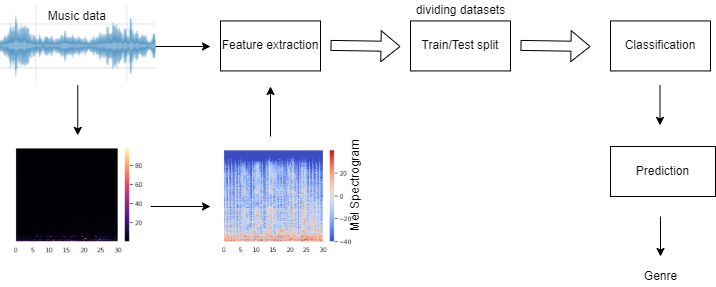

In [ ]:
# Loading a sample audio from the dataset
audio ="../input/gtzan-dataset-music-genre-classification/Data/genres_original/reggae/reggae.00010.wav"
data,sr=librosa.load(audio)
print(type(data),type(sr))

In order to work with audio data we use [Librosa](https://librosa.org/doc/latest/index.html), a python
package used for audio and music analysis. It is a powerful package widely used for
audio visualization and for building MIR systems. We will be using the package for
loading and visualizing the audio data.

In [ ]:
# Initializing sample rate to 45600 we obtain the signal value array
librosa.load(audio,sr=45600)

In [ ]:
# Taking Short-time Fourier transform of the signal
y = librosa.stft(data)  
S_db = librosa.amplitude_to_db(np.abs(y), ref=np.max)

In [ ]:
# Playing audio file
import IPython
IPython.display.Audio(data,rate=sr)

It is important to note that while working with any kind of audio data to solve any kind of problem statement, using only .wav format audio files is appropriate to analyze the data. If you are given audio files with .mp3 format you have to batch convert the data to waveforms using online software as .wav is the standard way of representing the audio files and it is the only way to work with audio data. Below is the wave form representation on the audio

In [ ]:
# Wave form of the audio
plt.figure(figsize=(7,4))
librosa.display.waveshow(data,color="#2B4F72", alpha = 0.5)
plt.show()

A spectrogram is a visual representation of the signal loudness of a signal over time at different frequencies included in a certain waveform. We can examine increase or decrease of energy over period of time. Spectrograms are also known as sonographs, voiceprints, and voicegrams.  We can also know how energy levels change over time period.

In [ ]:
# Spectrogram of the audio
stft=librosa.stft(data)
stft_db=librosa.amplitude_to_db(abs(stft))
plt.figure(figsize=(7,6))
librosa.display.specshow(stft_db,sr=sr,x_axis='time',y_axis='hz')
plt.colorbar()

## Data Pre Processing

### Extracting Audio features 
The process of extraction of features from the data to utilize them for analysis is
known as feature extraction. Each audio signal consists of various audio features
however we must extract features that are relevant to the problem that we are solving.
Here are some features listed which are used in our project.

### Spectral roll off 
It computes the rolloff frequency for each frame in a given signal. The frequency under which some percentage (cutoff) of the total energy of a spectrum is obtained. It can be used to differentiate between the harmonic and noisy sounds.   Spectral Roll off

In [ ]:
spectral_rolloff=librosa.feature.spectral_rolloff(y=data,sr=sr)[0]
plt.figure(figsize=(7,6))
librosa.display.waveshow(data,sr=sr,alpha=0.4,color="#2B4F72")

### Chroma feature 
It closely relates with the twelve different pitch classes. Chroma based features are also called as pitch class profiles. It is the powerful tool for analyzing and categorizing them. Harmonic and melodic characteristics of music are captured by them. Chroma featue

In [ ]:
import librosa.display as lplt
chroma = librosa.feature.chroma_stft(y=data,sr=sr)
plt.figure(figsize=(7,4))
lplt.specshow(chroma,sr=sr,x_axis="time",y_axis="chroma",cmap="BuPu")
plt.colorbar()
plt.title("Chroma Features")
plt.show()

### Zero Crossing Rate
It is the rate at which a signal transitions from positive to zero to negative or from negative to zero or simply said the number of times the signal crosses x-axis is as the zero-crossing rate (ZCR). 

In [ ]:
start=1000
end=1200
plt.figure(figsize=(12,4))
plt.plot(data[start:end],color="#2B4F72")

In [ ]:
# Printing the number of times signal crosses the x-axis
zero_cross_rate=librosa.zero_crossings(data[start:end],pad=False)
print("The number of zero_crossings are :", sum(zero_cross_rate))

## Exploratory Data Analysis(EDA)
Vizualizing the audio files, wave plots and spectrograms for all the 10 genre classes

In [ ]:
# EDA for all the music genre classes

# 1. BLUES 
audio1= '../input/gtzan-dataset-music-genre-classification/Data/genres_original/blues/blues.00001.wav'
data, sr = librosa.load(audio1)
plt.figure(figsize=(7, 3))
librosa.display.waveshow(data, sr=sr,alpha=0.4,)
plt.title('Waveplot - BLUES')

# Creating log mel spectrogram
plt.figure(figsize=(7, 4))
spectrogram = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128,fmax=8000) 
spectrogram = librosa.power_to_db(spectrogram)
librosa.display.specshow(spectrogram, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram - BLUES')
plt.colorbar(format='%+2.0f dB');
# playing audio
ipd.Audio(audio1) 

In [ ]:
# 2. CLASSICAL -
audio1= '../input/gtzan-dataset-music-genre-classification/Data/genres_original/classical/classical.00001.wav'
data, sr = librosa.load(audio1)
plt.figure(figsize=(7, 3))
librosa.display.waveshow(data, sr=sr,alpha=0.4)
plt.title('Waveplot - CLASSICAL') 

# Creating log mel spectrogram
plt.figure(figsize=(7, 4))
spectrogram = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128,fmax=8000) 
spectrogram = librosa.power_to_db(spectrogram)
librosa.display.specshow(spectrogram, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram -CLASSICAL')
plt.colorbar(format='%+2.0f dB');

# playing audio
ipd.Audio(audio1) 

In [ ]:
# 3. COUNTRY
audio1= '../input/gtzan-dataset-music-genre-classification/Data/genres_original/country/country.00001.wav'
data, sr = librosa.load(audio1)
plt.figure(figsize=(7, 3))
librosa.display.waveshow(data, sr=sr,alpha=0.4)
plt.title('Waveplot - COUNTRY')

# Ccreating log mel spectrogram
plt.figure(figsize=(7, 4))
spectrogram = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128,fmax=8000) 
spectrogram = librosa.power_to_db(spectrogram)
librosa.display.specshow(spectrogram, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram - COUNTRY')
plt.colorbar(format='%+2.0f dB');

# playing audio
ipd.Audio(audio1)

In [ ]:
# 4. DISCO
audio1= '../input/gtzan-dataset-music-genre-classification/Data/genres_original/disco/disco.00001.wav'
data, sr = librosa.load(audio1)
plt.figure(figsize=(7, 3))
librosa.display.waveshow(data, sr=sr,alpha=0.4)
plt.title('Waveplot - DISCO')

# Creating log mel spectrogram
plt.figure(figsize=(7, 4))
spectrogram = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128,fmax=8000) 
spectrogram = librosa.power_to_db(spectrogram)
librosa.display.specshow(spectrogram, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram - DISCO')
plt.colorbar(format='%+2.0f dB');
# playing audio
ipd.Audio(audio1) 

In [ ]:
# 5. HIPHOP
audio1= '../input/gtzan-dataset-music-genre-classification/Data/genres_original/hiphop/hiphop.00001.wav'
data, sr = librosa.load(audio1)
plt.figure(figsize=(7, 3))
librosa.display.waveshow(data, sr=sr, alpha = 0.4)
plt.title('Waveplot - HIPHOP')

# Creating log mel spectrogram 
plt.figure(figsize=(7, 4))
spectrogram = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128,fmax=8000,) 
spectrogram = librosa.power_to_db(spectrogram)
librosa.display.specshow(spectrogram, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram - HIPHOP')
plt.colorbar(format='%+2.0f dB');

# playing audio
ipd.Audio(audio1)

In [ ]:
# 6. JAZZ
audio1= '../input/gtzan-dataset-music-genre-classification/Data/genres_original/jazz/jazz.00001.wav'
data, sr = librosa.load(audio1)
plt.figure(figsize=(7, 3))
librosa.display.waveshow(data, sr=sr,alpha=0.4)
plt.title('Waveplot - JAZZ')

# Creating log mel spectrogram
plt.figure(figsize=(7, 4))
spectrogram = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128,fmax=8000) 
spectrogram = librosa.power_to_db(spectrogram)
librosa.display.specshow(spectrogram, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram - JAZZ')
plt.colorbar(format='%+2.0f dB');

# playing audio
ipd.Audio(audio1)

In [ ]:
# 7. METAL
audio1= '../input/gtzan-dataset-music-genre-classification/Data/genres_original/metal/metal.00001.wav'
data, sr = librosa.load(audio1)
plt.figure(figsize=(7, 3))
librosa.display.waveshow(data, sr=sr,alpha=0.4)
plt.title('Waveplot - METAL')

# creating log mel spectrogram
plt.figure(figsize=(7, 4))
spectrogram = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128,fmax=8000) 
spectrogram = librosa.power_to_db(spectrogram)
librosa.display.specshow(spectrogram, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram - METAL')
plt.colorbar(format='%+2.0f dB');

# playing audio
ipd.Audio(audio1)

In [ ]:
# 8. POP
audio1= '../input/gtzan-dataset-music-genre-classification/Data/genres_original/pop/pop.00001.wav'
data, sr = librosa.load(audio1)
plt.figure(figsize=(8, 3))
librosa.display.waveshow(data, sr=sr,alpha=0.4)
plt.title('Waveplot - POP') 

# Creating log mel spectrogram
plt.figure(figsize=(7, 4))
spectrogram = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128,fmax=8000) 
spectrogram = librosa.power_to_db(spectrogram)
librosa.display.specshow(spectrogram, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram - POP')
plt.colorbar(format='%+2.0f dB');

# playing audio
ipd.Audio(audio1)


In [ ]:
# 9. REGGAE
audio1= '../input/gtzan-dataset-music-genre-classification/Data/genres_original/reggae/reggae.00001.wav'
data, sr = librosa.load(audio1)
plt.figure(figsize=(7, 3))
librosa.display.waveshow(data, sr=sr,alpha=0.4)
plt.title('Waveplot - REGGAE')

# Creating log mel spectrogram
plt.figure(figsize=(7, 4))
spectrogram = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128,fmax=8000) 
spectrogram = librosa.power_to_db(spectrogram)
librosa.display.specshow(spectrogram, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram - REGGAE')
plt.colorbar(format='%+2.0f dB');

# playing audio
ipd.Audio(audio1)

In [ ]:
# 10.ROCK
audio1= '../input/gtzan-dataset-music-genre-classification/Data/genres_original/rock/rock.00001.wav'
data, sr = librosa.load(audio1)
plt.figure(figsize=(7, 3))
librosa.display.waveshow(data, sr=sr,alpha=0.4)
plt.title('Waveplot - ROCK')

# Creating log mel spectrogram
plt.figure(figsize=(7, 4))
spectrogram = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128,fmax=8000) 
spectrogram = librosa.power_to_db(spectrogram)
librosa.display.specshow(spectrogram, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram - ROCK')
plt.colorbar(format='%+2.0f dB');

# Playing audio
ipd.Audio(audio1)

In [ ]:
# Finding misssing values
# Find all columns with any NA values
print("Columns containing missing values",list(df.columns[df.isnull().any()]))

In [ ]:
# Label Encoding - encod the categorical classes with numerical integer values for training

# Blues - 0
# Classical - 1
# Country - 2
# Disco - 3
# Hip-hop - 4 
# Jazz - 5  
# Metal - 6 
# Pop - 7
# Reggae - 8
# Rock - 9

class_encod=df.iloc[:,-1]
converter=LabelEncoder()
y=converter.fit_transform(class_encod)
y

In [ ]:
#features
print(df.iloc[:,:-1])

In [ ]:
# Drop the column filename as it is no longer required for training
df=df.drop(labels="filename",axis=1)

In [ ]:
#scaling
from sklearn.preprocessing import StandardScaler
fit=StandardScaler()
X=fit.fit_transform(np.array(df.iloc[:,:-1],dtype=float))

In [ ]:
# splitting 70% data into training set and the remaining 30% to test set
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)

In [ ]:
# test data size
len(y_test)

In [ ]:
# size of training data
len(y_train)

## K-Nearest Neighbors (KNN)
KNN is a fundamental Machine learning algorithm that is most commonly used
among all kinds of problems. It classifies the data points based on the point that is
near them by finding the euclidians distance given by d = ((x2-x1)^2 - (y2-y1)^2)^1/2 as a metric.

In [ ]:
# Applying K nearest Neighbour algorithm to predict the results
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

clf1=KNeighborsClassifier(n_neighbors=3)
clf1.fit(X_train,y_train)
y_pred=clf1.predict(X_test)
print("Training set score: {:.3f}".format(clf1.score(X_train, y_train)))
print("Test set score: {:.3f}".format(clf1.score(X_test, y_test)))
cf_matrix = confusion_matrix(y_test, y_pred)
sns.set(rc = {'figure.figsize':(8,3)})
sns.heatmap(cf_matrix, annot=True)
print(classification_report(y_test,y_pred))

## Support Vector Machine (SVM)
SVM is one of the best machine learning models. Since the data is not linearly
separable, we have used the SVM kernel function as sigmoid. The sigmoid function is
given by
K(yn,yi) = tanh(-gamma*(yn,yi)+r)

In [ ]:
# Applying Support Vector Machines to predict the results
from sklearn.svm import SVC
svclassifier = SVC(kernel='rbf', degree=8)
svclassifier.fit(X_train, y_train)
print("Training set score: {:.3f}".format(svclassifier.score(X_train, y_train)))
print("Test set score: {:.3f}".format(svclassifier.score(X_test, y_test)))
y_pred = svclassifier.predict(X_test)
cf_matrix3 = confusion_matrix(y_test, y_pred)
sns.set(rc = {'figure.figsize':(9,4)})
sns.heatmap(cf_matrix3, annot=True)
print(classification_report(y_test, y_pred))

## Convolutional Neural Networks (CNN)
Using neural networks is the best way to classify huge data to draw predictions.
Convolutions can solve the given problem very precisely and the algorithm has already been
used most widely in classifying the image data. 

##### Model Architecture
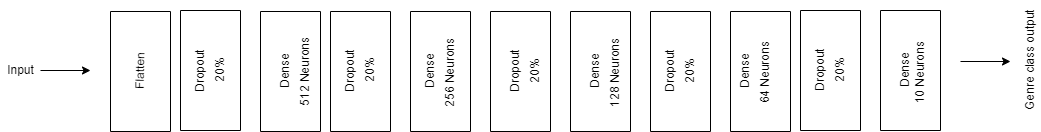

In [ ]:
# Training the model using the following parameters
# metrics = accuracy
# epochs = 600
# loss = sparse_categorical_crossentropy
# batch_size = 256
# optimizer = adam

def train_model(model,epochs,optimizer):
    batch_size=256
    model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics='accuracy')
    return model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=epochs,batch_size=batch_size)

In [ ]:
def Validation_plot(history):
    print("Validation Accuracy",max(history.history["val_accuracy"]))
    pd.DataFrame(history.history).plot(figsize=(12,6))
    plt.show()

Keras is the high-level API of TensorFlow 2: an approachable, highly-productive interface for solving machine learning problems, with a focus on modern deep learning. It provides essential abstractions and building blocks for developing and shipping machine learning solutions with high iteration velocity.

In [ ]:
# We used different layers to train the neural network by importing keras library from tensorflow framework 
# for input and hidden neurons we use the most widly used activation function which is relu where as for output neurons we uses softmax activation function
model=tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(X.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(512,activation='relu'),
    keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(10,activation='softmax'),
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.000146)
model.compile(optimizer=optimizer,
             loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()
model_history=train_model(model=model,epochs=600,optimizer='adam')


In [ ]:
test_loss,test_acc=model.evaluate(X_test,y_test,batch_size=256)
print("The test loss is ",test_loss)
print("The best accuracy is: ",test_acc*100)

In [ ]:
# The plot dipicts how training and testing data performed
Validation_plot(model_history)

In [ ]:
# Sample testing
sample = X_test
sample = sample[np.newaxis, ...]
prediction = model.predict(X_test)
predicted_index = np.argmax(prediction, axis = 1)
print("Expected Index: {}, Predicted Index: {}".format(y_test, predicted_index))

In [ ]:
# Plotting the confusion matrix for analizing the true positives and negatives
import seaborn as sn
import matplotlib.pyplot as plt
pred_x = model.predict(X_test)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,predicted_index )
cm


## Conclusion
As expected CNN outperformed KNN and SVM. It produced best results in both testing and taring data. As we increased the number of epochs the loss percentage decreased with a gradual increase in accuracy scores. It can be clearly seen in the above validation plot in which the curves almost coincided with each other.

## References

1.[https://www.tensorflow.org/datasets/catalog/gtzan](https://www.tensorflow.org/datasets/catalog/gtzan)

2.[https://www.kaggle.com/code/dapy15/music-genre-classification](https://www.kaggle.com/code/dapy15/music-genre-classification)

3.[https://www.clairvoyant.ai/blog/music-genre-classification-using-cnn](https://www.clairvoyant.ai/blog/music-genre-classification-using-cnn)

4.[https://github.com/alikaratana/Music-Genre-Classification](https://github.com/alikaratana/Music-Genre-Classification)